In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [2]:
columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv("wdbc.data", header=None, names=columns)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 32)


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df["Diagnosis"].value_counts())

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (569, 32)

Missing Values:
0

Class Distribution:
Diagnosis
B    357
M    212
Name: count, dtype: int64

Data Types:
float64    30
int64       1
object      1
Name: count, dtype: int64

Statistical Summary:


,ID,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


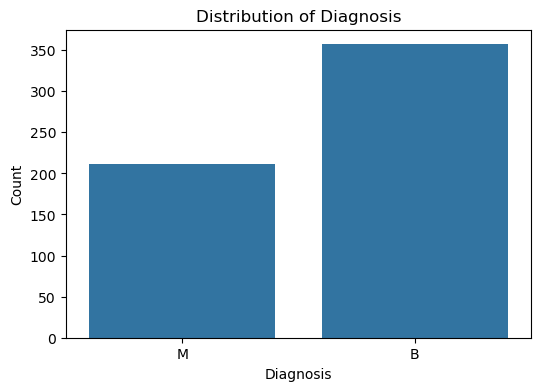

In [4]:
 plt.figure(figsize=(6, 4))

sns.countplot(x="Diagnosis", data=df)

plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

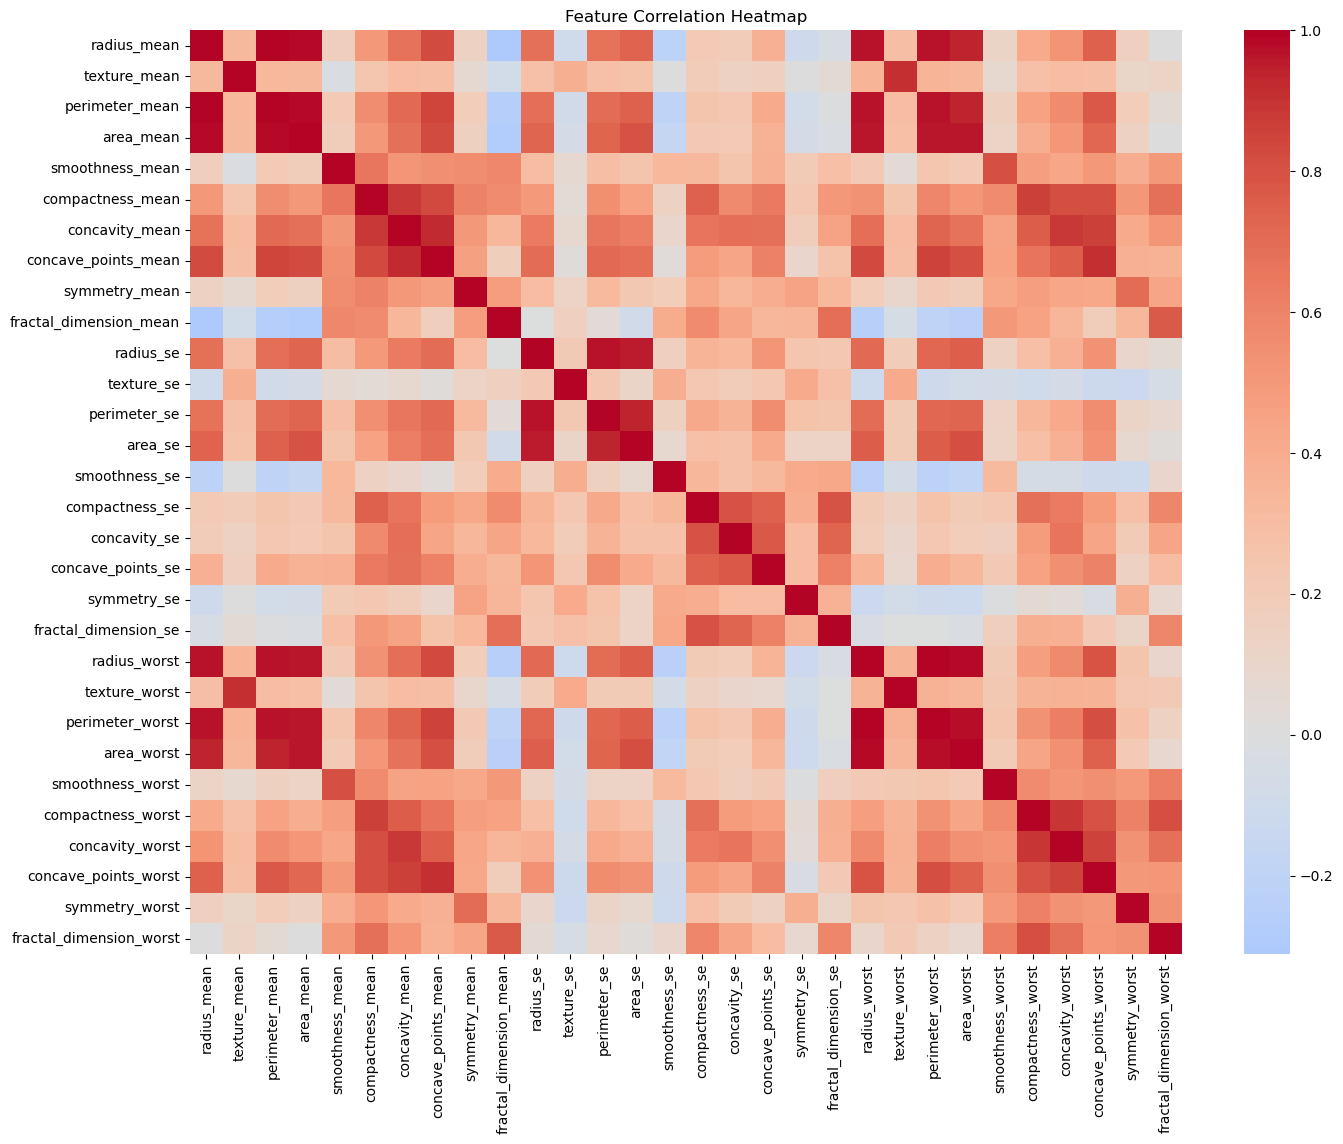

In [5]:
plt.figure(figsize=(16, 12))

correlation = df.drop(columns=["ID", "Diagnosis"]).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
feature_stats = df.groupby("Diagnosis")[
    ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean"]
].mean().round(2)

feature_stats

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean
Diagnosis,,,,,
B,12.15,17.91,78.08,462.79,0.09
M,17.46,21.60,115.37,978.38,0.10


In [7]:
X = df.drop(columns=["ID", "Diagnosis"])

y = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Mapping:")
print("B = 0")
print("M = 1")

Feature Shape: (569, 30)
Target Shape: (569,)

Target Mapping:
B = 0
M = 1


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 455
Testing Samples: 114


In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation created.")

5-Fold Cross-Validation created.


In [10]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

bagging_params = {
    "n_estimators": [10, 25, 50, 100],
    "max_samples": [0.8],
    "max_features": [1.0]
}

print("Bagging model created.")
print("Hyperparameters to evaluate:")
print(bagging_params)

Bagging model created.
Hyperparameters to evaluate:
{'n_estimators': [10, 25, 50, 100], 'max_samples': [0.8], 'max_features': [1.0]}


In [11]:
bagging_results = []

for n in [10, 25, 50, 100]:

    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n,
        max_samples=0.8,
        max_features=1.0,
        random_state=42
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1"]
    )

    bagging_results.append([
        n,
        0.8,
        1.0,
        scores["test_accuracy"].mean() * 100,
        scores["test_f1"].mean() * 100
    ])


bagging_table = pd.DataFrame(
    bagging_results,
    columns=[
        "n estimators",
        "max samples",
        "max features",
        "Avg CV Accuracy (%)",
        "Avg CV F1 Score (%)"
    ]
)

bagging_table = bagging_table.round(2)

print("TABLE 1: BAGGING HYPERPARAMETER EVALUATION")
display(bagging_table)

TABLE 1: BAGGING HYPERPARAMETER EVALUATION


,n estimators,max samples,max features,Avg CV Accuracy (%),Avg CV F1 Score (%)
0,10,0.8,1.0,94.51,92.26
1,25,0.8,1.0,96.92,95.85
2,50,0.8,1.0,96.48,95.26
3,100,0.8,1.0,95.60,93.99


In [12]:
best_bagging_row = bagging_table.loc[
    bagging_table["Avg CV Accuracy (%)"].idxmax()
]

best_n = int(best_bagging_row["n estimators"])

best_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=best_n,
    max_samples=0.8,
    max_features=1.0,
    random_state=42
)

best_bagging.fit(X_train, y_train)

print("Best Bagging Configuration:")
print("n_estimators =", best_n)
print("max_samples =", 0.8)
print("max_features =", 1.0)

Best Bagging Configuration:
n_estimators = 25
max_samples = 0.8
max_features = 1.0


In [13]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    random_state=42
)

gradient_model = GradientBoostingClassifier(
    random_state=42
)

print("AdaBoost and Gradient Boosting models created.")

AdaBoost and Gradient Boosting models created.


In [14]:
ada_results = []

for n in [50, 100]:

    for lr in [0.5, 1.0]:

        model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=1,
                random_state=42
            ),
            n_estimators=n,
            learning_rate=lr,
            random_state=42
        )

        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=["accuracy", "f1"]
        )

        ada_results.append([
            "AdaBoost",
            n,
            lr,
            1,
            scores["test_accuracy"].mean() * 100,
            scores["test_f1"].mean() * 100
        ])

In [15]:
gradient_results = []

for n in [50, 100]:

    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1"]
    )

    gradient_results.append([
        "Gradient Boosting",
        n,
        0.1,
        3,
        scores["test_accuracy"].mean() * 100,
        scores["test_f1"].mean() * 100
    ])

In [16]:
boosting_results = ada_results + gradient_results

boosting_table = pd.DataFrame(
    boosting_results,
    columns=[
        "Model",
        "n estimators",
        "learning rate",
        "max depth",
        "Avg CV Accuracy (%)",
        "Avg CV F1 Score (%)"
    ]
)

boosting_table = boosting_table.round(2)

print("TABLE 2: BOOSTING HYPERPARAMETER EVALUATION")
display(boosting_table)

TABLE 2: BOOSTING HYPERPARAMETER EVALUATION


,Model,n estimators,learning rate,max depth,Avg CV Accuracy (%),Avg CV F1 Score (%)
0,AdaBoost,50,0.5,1,96.48,95.12
1,AdaBoost,50,1.0,1,96.70,95.46
2,AdaBoost,100,0.5,1,97.14,96.07
3,AdaBoost,100,1.0,1,96.48,95.23
4,Gradient Boosting,50,0.1,3,95.60,94.09
5,Gradient Boosting,100,0.1,3,96.70,95.53


In [17]:
best_boosting_row = boosting_table.loc[
    boosting_table["Avg CV Accuracy (%)"].idxmax()
]

best_model_name = best_boosting_row["Model"]

if best_model_name == "AdaBoost":

    best_boosting = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=int(best_boosting_row["n estimators"]),
        learning_rate=best_boosting_row["learning rate"],
        random_state=42
    )

else:

    best_boosting = GradientBoostingClassifier(
        n_estimators=int(best_boosting_row["n estimators"]),
        learning_rate=best_boosting_row["learning rate"],
        max_depth=int(best_boosting_row["max depth"]),
        random_state=42
    )

best_boosting.fit(X_train, y_train)

print("Best Boosting Model:", best_model_name)
print("Best Parameters:")
print(best_boosting_row)

Best Boosting Model: AdaBoost
Best Parameters:
Model                  AdaBoost
n estimators                100
learning rate               0.5
max depth                     1
Avg CV Accuracy (%)       97.14
Avg CV F1 Score (%)       96.07
Name: 2, dtype: object


In [18]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        probability=True,
        random_state=42
    ))
])

nb_model = GaussianNB()

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Base Models:")
print("1. SVM")
print("2. Naive Bayes")
print("3. Decision Tree")

print("\nMeta Learner:")
print("Logistic Regression")

Base Models:
1. SVM
2. Naive Bayes
3. Decision Tree

Meta Learner:
Logistic Regression


In [19]:
stacking_model = StackingClassifier(
    estimators=[
        ("svm", svm_model),
        ("nb", nb_model),
        ("dt", dt_model)
    ],
    final_estimator=meta_model,
    cv=5
)

print("Stacked Ensemble created successfully.")

Stacked Ensemble created successfully.


In [20]:
stacking_scores = cross_validate(
    stacking_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "f1"]
)

stacking_accuracy = stacking_scores["test_accuracy"].mean() * 100
stacking_f1 = stacking_scores["test_f1"].mean() * 100

print("Average CV Accuracy:", round(stacking_accuracy, 2), "%")
print("Average CV F1 Score:", round(stacking_f1, 2), "%")

Average CV Accuracy: 96.26 %
Average CV F1 Score: 94.9 %


In [21]:
stacking_table = pd.DataFrame({
    "Base Models": [
        "SVM + Naive Bayes + Decision Tree"
    ],
    "Meta Learner": [
        "Logistic Regression"
    ],
    "Avg CV Accuracy (%)": [
        stacking_accuracy
    ],
    "Avg CV F1 Score (%)": [
        stacking_f1
    ]
})

stacking_table = stacking_table.round(2)

print("TABLE 3: STACKED ENSEMBLE EVALUATION")
display(stacking_table)

TABLE 3: STACKED ENSEMBLE EVALUATION


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score (%)
0,SVM + Naive Bayes + Decision Tree,Logistic Regression,96.26,94.9


In [23]:
best_bagging.fit(X_train, y_train)
best_boosting.fit(X_train, y_train)
stacking_model.fit(X_train, y_train)

print("Final models trained successfully.")

final_models = {
    "Bagging": best_bagging,
    "Boosting": best_boosting,
    "Stacked Ensemble": stacking_model
}

performance_results = []

for name, model in final_models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred) * 100
    recall = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100

    performance_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

performance_table = pd.DataFrame(
    performance_results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)"
    ]
)

performance_table = performance_table.round(2)

print("TABLE 4: PERFORMANCE COMPARISON")
display(performance_table)

Final models trained successfully.
TABLE 4: PERFORMANCE COMPARISON


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Bagging,97.37,100.0,92.86,96.3
1,Boosting,97.37,100.0,92.86,96.3
2,Stacked Ensemble,96.49,100.0,90.48,95.0


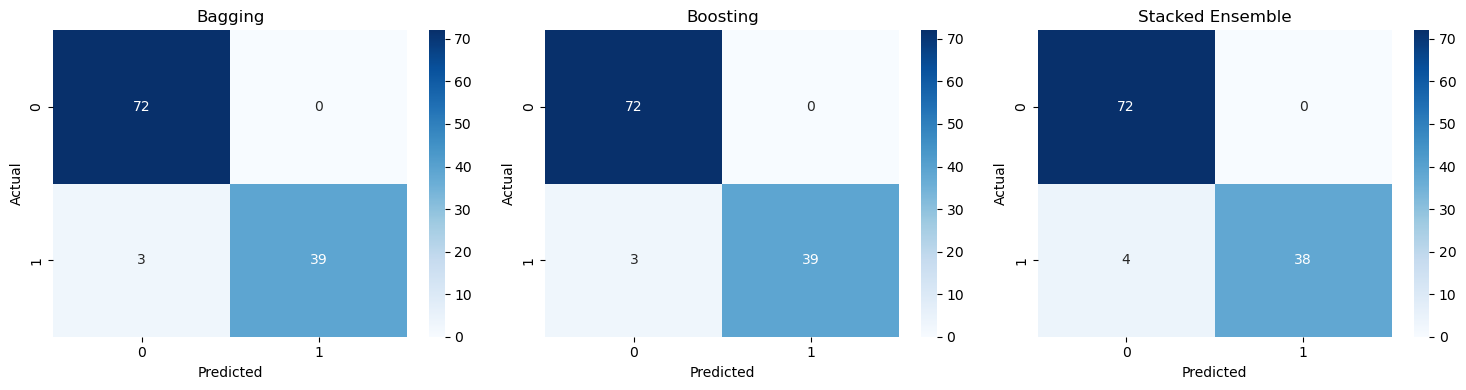

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, final_models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

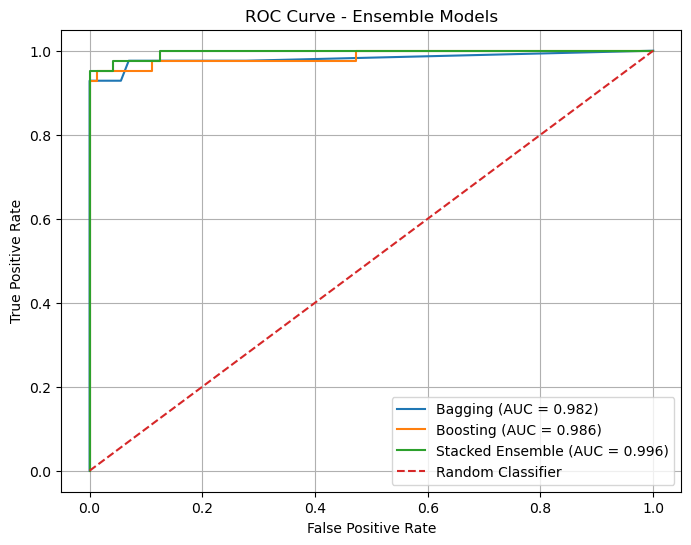

In [25]:
plt.figure(figsize=(8, 6))

auc_results = {}

for name, model in final_models.items():

    y_probability = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    auc_results[name] = auc

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ensemble Models")
plt.legend()
plt.grid()
plt.show()

In [26]:
auc_table = pd.DataFrame({
    "Model": list(auc_results.keys()),
    "AUC": list(auc_results.values())
})

auc_table["AUC"] = auc_table["AUC"].round(3)

print("ROC-AUC COMPARISON")
display(auc_table)

ROC-AUC COMPARISON


,Model,AUC
0,Bagging,0.982
1,Boosting,0.986
2,Stacked Ensemble,0.996


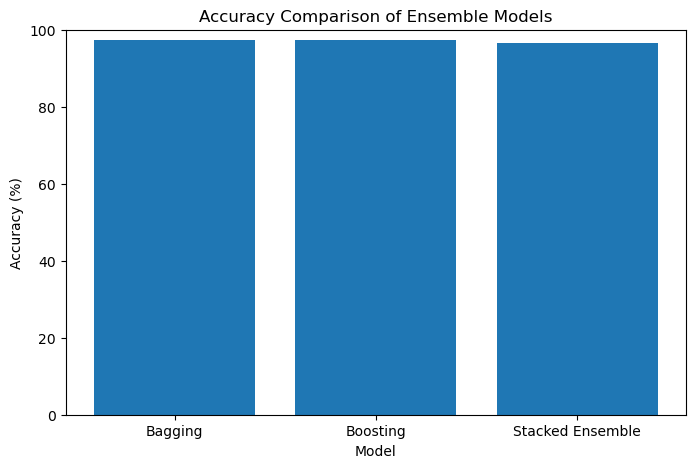

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    performance_table["Model"],
    performance_table["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Ensemble Models")
plt.ylim(0, 100)

plt.show()